### Introduction

This notebook assesses the quality of the smartwatch sensor recordings contained in the movement dataset of the Parkinson's Disease Smartwatch (PADS) database. The analysis focuses on the accelerometer and gyroscope signals collected during neurological assessment tasks to verify that the recordings are complete, valid, and suitable for feature extraction and machine learning.

Dataset located in: "data/raw/movement"

This directory contains two types of files:

##### a. Observation JSON files
These files store metadata describing each participant's neurological assessment sessions, including:

- Participant identifier
- Assessment task name
- Sampling rate
- Number of recorded samples
- Sensor channels
- Device location (LeftWrist or RightWrist)
- Reference to the corresponding time-series file

##### b. Time-series files (timeseries/*.txt)
These files contain the raw smartwatch measurements recorded during each neurological assessment task. Each file includes the following channels:

- Time
- Accelerometer_X
- Accelerometer_Y
- Accelerometer_Z
- Gyroscope_X
- Gyroscope_Y
- Gyroscope_Z

#### Objetives

- Process and review accelerometer and gyroscope time-series data from all participants.
- Evaluate the completeness and availability of sensor channels across participants and assessment conditions.
- Identify and characterize signal quality issues, noisy, incomplete, or invalid sensor recordings.
- Perform exploratory visualization of representative accelerometer and gyroscope signals.
- Develop a Signal Quality Report summarizing the results of the quality assessment. 
- Establish signal-quality assessment rules based on exploratory analysis results.

#### 1. Loaing Raw Signal Data

In [ ]:
# Impor libraries
from pathlib import Path
import json
import pandas as pd

# Define paths
movement_path = Path("../data/raw/movement")

print(f"Movement directory: {movement_path.resolve()}")
print(f"Directory exists: {movement_path.exists()}")

# Read all JSON files
json_files = sorted(movement_path.glob("*.json"))

print(f"Number of files: {len(json_files)}")

Movement directory: C:\Users\Main\Documents\GitHub\AI-Assisted-Screening-of-Parkinson-s-Disease\data\raw\movement
Directory exists: True
Number of files: 469


In [ ]:
# Load the files
sensor_data = []

for file in json_files:
    with open(file, "r") as f:
        sensor_data.append(json.load(f))

print(f"Loaded {len(sensor_data)} recordings.")

# Verify that they were loaded correctly
print(sensor_data[0].keys())

Loaded 469 recordings.
dict_keys(['resource_type', 'subject_id', 'study_id', 'device_id', 'id', 'endianness', 'sampling_rate', 'data_type', 'bits', 'session'])


#### 2. Inspecting the Dataset Structure
Verify the completeness of sensor channels for each participant and assessment task.

In [ ]:
from pprint import pprint

# Verify the completeness of sensor channels
required_channels = {
    "Time",
    "Accelerometer_X",
    "Accelerometer_Y",
    "Accelerometer_Z",
    "Gyroscope_X",
    "Gyroscope_Y",
    "Gyroscope_Z"
}

In [ ]:
completeness = []

for observation in sensor_data:

    subject = observation["subject_id"]

    for session in observation["session"]:

        task = session["record_name"]

        for record in session["records"]:

            location = record["device_location"]

            channels = set(record["channels"])

            missing = required_channels - channels

            completeness.append({
                "Subject": subject,
                "Task": task,
                "Location": location,
                "Complete": len(missing) == 0,
                "Missing Channels": ", ".join(sorted(missing)) if missing else "None"
            })

completeness_df = pd.DataFrame(completeness)

completeness_df.head()

,Subject,Task,Location,Complete,Missing Channels
0,001,Relaxed,LeftWrist,True,None
1,001,Relaxed,RightWrist,True,None
2,001,RelaxedTask,LeftWrist,True,None
3,001,RelaxedTask,RightWrist,True,None
4,001,StretchHold,LeftWrist,True,None


#### 3. Detect constant, noisy, incomplete, or invalid signals

Evaluate the quality of every accelerometer and gyroscope recording by checking signal completeness, missing values, constant channels and invalid values

#### 3.1 Load and Inspect a Sample Signal

In [ ]:
# Define the folder where the time series (.txt) are located.
timeseries_path = Path("../data/raw/movement/timeseries")

print(timeseries_path.exists())

True


In [ ]:
# sensor_data[0] correspont to observation_001.json
# Store all txt files from observation_001
observation_files = []

for session in sensor_data[0]["session"]:
    for record in session["records"]:
        observation_files.append(record["file_name"])

print("Number of files:", len(observation_files))
observation_files

Number of files: 22


['timeseries/001_Relaxed_LeftWrist.txt',
 'timeseries/001_Relaxed_RightWrist.txt',
 'timeseries/001_RelaxedTask_LeftWrist.txt',
 'timeseries/001_RelaxedTask_RightWrist.txt',
 'timeseries/001_StretchHold_LeftWrist.txt',
 'timeseries/001_StretchHold_RightWrist.txt',
 'timeseries/001_LiftHold_LeftWrist.txt',
 'timeseries/001_LiftHold_RightWrist.txt',
 'timeseries/001_HoldWeight_LeftWrist.txt',
 'timeseries/001_HoldWeight_RightWrist.txt',
 'timeseries/001_PointFinger_LeftWrist.txt',
 'timeseries/001_PointFinger_RightWrist.txt',
 'timeseries/001_DrinkGlas_LeftWrist.txt',
 'timeseries/001_DrinkGlas_RightWrist.txt',
 'timeseries/001_CrossArms_LeftWrist.txt',
 'timeseries/001_CrossArms_RightWrist.txt',
 'timeseries/001_TouchIndex_LeftWrist.txt',
 'timeseries/001_TouchIndex_RightWrist.txt',
 'timeseries/001_TouchNose_LeftWrist.txt',
 'timeseries/001_TouchNose_RightWrist.txt',
 'timeseries/001_Entrainment_LeftWrist.txt',
 'timeseries/001_Entrainment_RightWrist.txt']

#### 3.2 Perform Signal Quality for all recordings (Outliers signals)

In [ ]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt

In [ ]:
# Evaluate the quality of all recordings in the dataset.

# List where we will save the results
quality_results = []

for observation in sensor_data:

    subject = observation["subject_id"]

    for session in observation["session"]:

        task = session["record_name"]
        expected_rows = session["rows"]

        for record in session["records"]:

            location = record["device_location"]

            columns = record["channels"]

            # Read one recording
            signal = pd.read_csv(
                timeseries_path / Path(record["file_name"]).name,
                header=None,
                names=columns
            )


            # Quality checks
            actual_rows = len(signal)

            missing_values = signal.isna().sum().sum()

            constant_channels = signal.columns[signal.std() == 0].tolist()

            invalid_values = np.isinf(signal.values).sum()

            # Outlier calculation
            sensor_values = signal.iloc[:, 1:]   # Exclude Time

            z_scores = np.abs(
                (sensor_values - sensor_values.mean()) /
                sensor_values.std()
            )

            outlier_count = (z_scores > 3).sum().sum()

            total_values = sensor_values.size

            outlier_percentage = (outlier_count / total_values) * 100

            # Classification            
            if actual_rows != expected_rows:
                quality = "Incomplete"

            elif missing_values > 0:
                quality = "Missing Values"

            elif invalid_values > 0:
                quality = "Invalid"

            elif len(constant_channels) > 0:
                quality = "Constant"

            else:
                quality = "Valid"

            # Save results
            quality_results.append({

                "Subject": subject,
                "Task": task,
                "Location": location,
                "File": Path(record["file_name"]).name,


                "Expected Rows": expected_rows,
                "Actual Rows": actual_rows,

                "Missing Values": missing_values,
                "Constant Channels": ", ".join(constant_channels) if constant_channels else "None",
                "Invalid Values": invalid_values,
                
                "Outlier (%)": round(outlier_percentage, 3),

                "Quality": quality

            })

In [ ]:
# Explore the outlier signal distribution
quality_report = pd.DataFrame(quality_results)

quality_report["Outlier (%)"].describe()

count    10318.000000
mean         1.231707
std          0.998225
min          0.000000
25%          0.488000
50%          0.879000
75%          1.709000
max          4.948000
Name: Outlier (%), dtype: float64

In [ ]:
quality_report[["Subject", "Task", "Location", "Outlier (%)"]] \
    .sort_values(by="Outlier (%)", ascending=False) \
    .head(10)

,Subject,Task,Location,Outlier (%)
9665,440,LiftHold,RightWrist,4.948
6240,284,CrossArms,LeftWrist,4.932
2017,092,CrossArms,RightWrist,4.818
8917,406,LiftHold,RightWrist,4.785
9664,440,LiftHold,LeftWrist,4.753
7288,332,LiftHold,LeftWrist,4.704
2544,116,CrossArms,LeftWrist,4.688
3205,146,CrossArms,RightWrist,4.688
3249,148,CrossArms,RightWrist,4.655
7772,354,LiftHold,LeftWrist,4.655


#### Observation:

A total of 10,318 recordings were analyzed. The percentage of statistical outliers was generally low, with an average Outlier (%) of 1.232%. Half of the recordings contained less than 0.879% outliers, while 75% of the recordings had 1.709% or fewer outliers, indicating that most recordings exhibit a relatively small proportion of extreme values.

Although a small number of recordings reached Outlier (%) values of up to 4.95%, these cases were primarily associated with the LiftHold and CrossArms assessment tasks, which involve more dynamic wrist movements and are therefore expected to produce greater signal variability.

#### 4. Visualize of Accelerometer and Gyroscope Signals

#### 4.1 Accelerometer signals (right and left)

Subject: 002
Task: Relaxed
Location: LeftWrist
File: 002_Relaxed_LeftWrist.txt


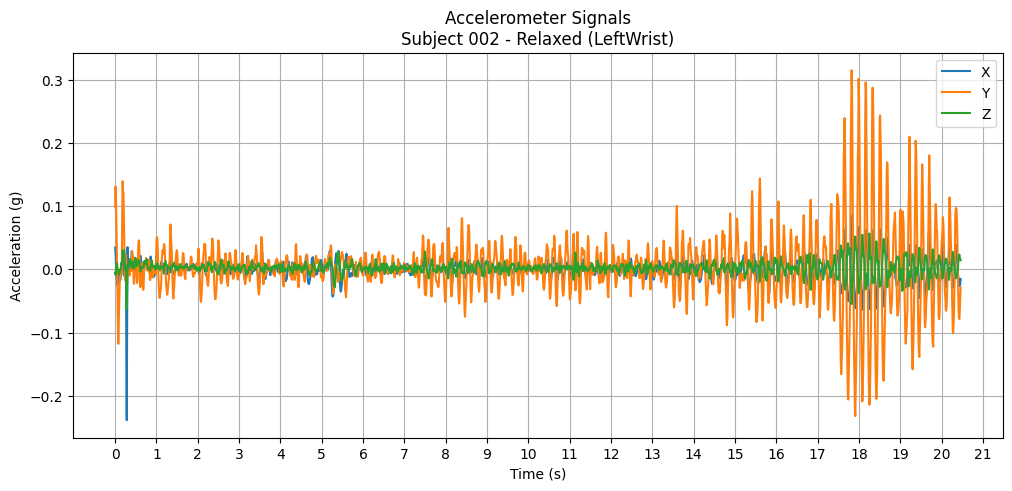

,Time,Accelerometer_X,Accelerometer_Y,Accelerometer_Z
0,0.000000,0.034292,0.098250,-0.005072
1,0.009733,0.026288,0.130978,-0.008518
2,0.019759,0.009783,0.107032,0.000305
3,0.029654,0.000151,0.069063,0.009437
4,0.039721,-0.013495,0.037050,0.008749


In [ ]:
# Select a sample recording (Left) for inspection
observation = sensor_data[1]          # observation_002.json
subject = observation["subject_id"]   # Patient ID

session = observation["session"][0]   # [0] First assessment task
task = session["record_name"]

record_selection_0 = session["records"][0]        # recording (Left (0) or Right (1) wrist)
location_0 = record_selection_0["device_location"]

columns = record_selection_0["channels"]

#Load the signal
signal = pd.read_csv(
    timeseries_path / Path(record_selection_0["file_name"]).name,
    header=None,
    names=columns
)

# Display information about the selected recording
print(f"Subject: {subject}")
print(f"Task: {task}")
print(f"Location: {location_0}")
print(f"File: {Path(record_selection_0['file_name']).name}")

plt.figure(figsize=(12,5))

plt.plot(signal["Time"], signal["Accelerometer_X"], label="X")
plt.plot(signal["Time"], signal["Accelerometer_Y"], label="Y")
plt.plot(signal["Time"], signal["Accelerometer_Z"], label="Z")

plt.title(f"Accelerometer Signals\nSubject {subject} - {task} ({location_0})")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")

# Show ticks every second
plt.xticks(np.arange(0, signal["Time"].max() + 1, 1))
plt.legend()
plt.grid(True)
plt.show()

# Show table
signal[["Time","Accelerometer_X","Accelerometer_Y","Accelerometer_Z"]].head()

#### Observation:
The accelerometer signals for Subject 002 during the Relaxed task show a low-amplitude oscillations centered around zero, which is consistent with a relaxed posture. Toward the end of the recording (approximately between 17 and 20 seconds), the amplitude of the Y-axis increases noticeably, while the X and Z axes also show moderate variations.

Subject: 001
Task: Relaxed
Location: RightWrist
File: 001_Relaxed_RightWrist.txt


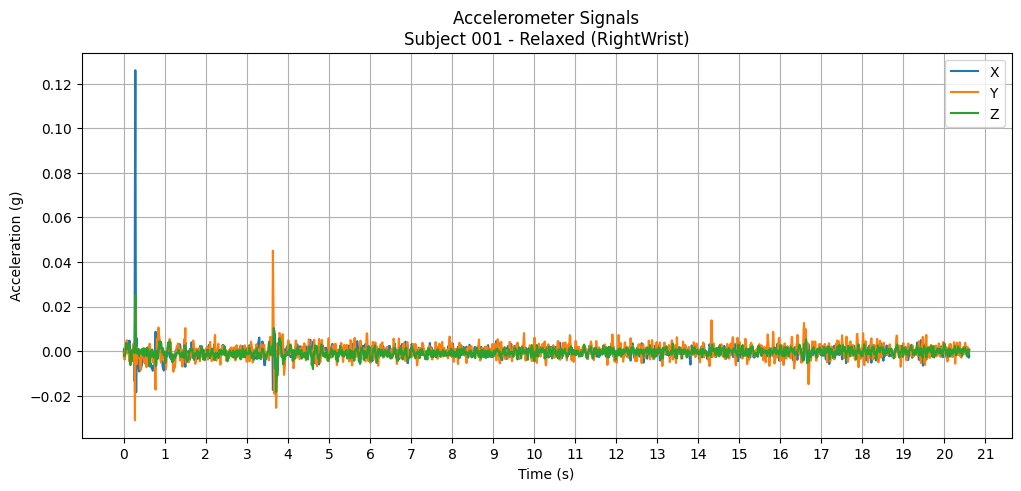

,Time,Accelerometer_X,Accelerometer_Y,Accelerometer_Z
0,0.000000,-0.000743,-0.000785,-0.002034
1,0.009799,0.001157,-0.001839,-0.002086
2,0.020041,0.001118,-0.003838,-0.001165
3,0.030082,0.000113,-0.000967,-0.002196
4,0.040679,0.000075,0.002900,-0.001224


In [ ]:
# Select a sample recording (right) for inspection
observation = sensor_data[0]          # observation_001.json
subject = observation["subject_id"]   # Patient ID

session = observation["session"][0]   # [0] First assessment task
task = session["record_name"]

record_selection_1 = session["records"][1]        # First recording (Left (0) or Right (1) wrist)
location_1 = record_selection_1["device_location"]

columns = record_selection_1["channels"]

#Load the signal
signal = pd.read_csv(
    timeseries_path / Path(record_selection_1["file_name"]).name,
    header=None,
    names=columns
)

# Display information about the selected recording
print(f"Subject: {subject}")
print(f"Task: {task}")
print(f"Location: {location_1}")
print(f"File: {Path(record_selection_1['file_name']).name}")

plt.figure(figsize=(12,5))

plt.plot(signal["Time"], signal["Accelerometer_X"], label="X")
plt.plot(signal["Time"], signal["Accelerometer_Y"], label="Y")
plt.plot(signal["Time"], signal["Accelerometer_Z"], label="Z")

plt.title(f"Accelerometer Signals\nSubject {subject} - {task} ({location_1})")
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (g)")

# Show ticks every second
plt.xticks(np.arange(0, signal["Time"].max() + 1, 1))
plt.legend()
plt.grid(True)
plt.show()

# Show table
signal[["Time","Accelerometer_X","Accelerometer_Y","Accelerometer_Z"]].head()

#### Observation:

The accelerometer recordings for Subject 001 during the Relaxed task show that most samples remain close to zero acceleration, which is expected during a relaxed assessment with limited wrist movement. A few isolated peaks are visible, particularly on the X-axis near the beginning of the recording and on the Y-axis around 3–4 seconds.

Besides, no missing segments or constant signals are observed, indicating that the accelerometer collected data consistently

#### 4.2 Gyroscope signal

Subject: 001
Task: Relaxed
Location: RightWrist
File: 001_Relaxed_RightWrist.txt


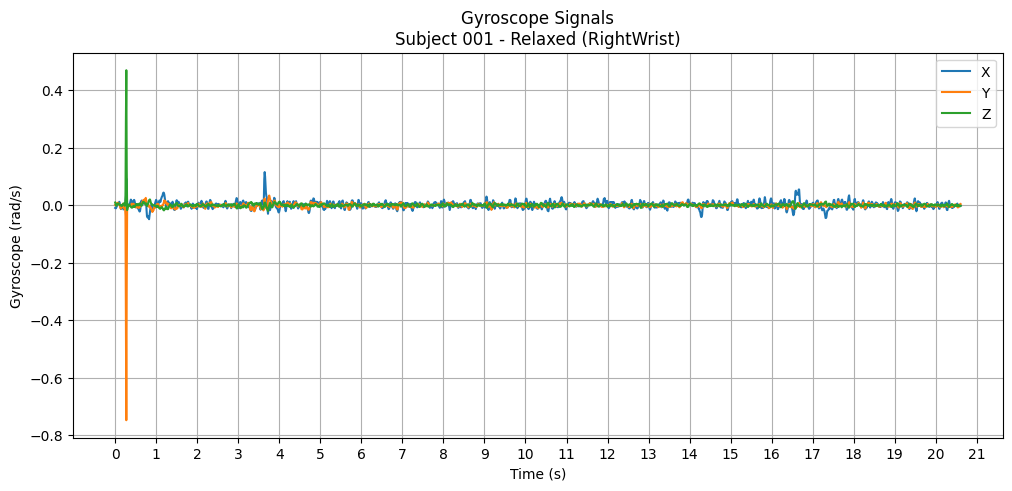

,Time,Gyroscope_X,Gyroscope_Y,Gyroscope_Z
0,0.000000,-0.009274,0.001274,0.009687
1,0.009799,-0.010353,0.002298,0.005441
2,0.020041,-0.010367,0.003324,0.000132
3,0.030082,-0.006997,0.005392,-0.001923
4,0.040679,-0.003816,0.007570,0.002324


In [ ]:
# Display information about the selected recording.  
# In this graphic, we still used the recording from the previous cell (observation 001)
print(f"Subject: {subject}")
print(f"Task: {task}")
print(f"Location: {location_1}")                             # Change 0 to left and 1 to right
print(f"File: {Path(record_selection_1['file_name']).name}") # Change 0 to left and 1 to right
plt.figure(figsize=(12,5))

plt.plot(signal["Time"], signal["Gyroscope_X"], label="X")
plt.plot(signal["Time"], signal["Gyroscope_Y"], label="Y")
plt.plot(signal["Time"], signal["Gyroscope_Z"], label="Z")

plt.title(f"Gyroscope Signals\nSubject {subject} - {task} ({location_1})") # Change 0 to left and 1 to right
plt.xlabel("Time (s)")
plt.ylabel("Gyroscope (rad/s)")

# Show ticks every second
plt.xticks(np.arange(0, signal["Time"].max() + 1, 1))
plt.legend()
plt.grid(True)

plt.show()

# Show table
signal[["Time","Gyroscope_X","Gyroscope_Y","Gyroscope_Z"]].head()

#### Observation:

The gyroscope signals remain continuous throughout the recording, with angular velocity values generally centered around zero. A few isolated peaks are visible at the beginning of the recording. According to the PADS dataset preprocessing procedure, these initial peaks correspond to the smartwatch notification vibration that marks the beginning of the assessment.

#### 5. Signal Quality Report

In [ ]:
quality_report

,Subject,Task,Location,File,Expected Rows,Actual Rows,Missing Values,Constant Channels,Invalid Values,Outlier (%),Quality
0,001,Relaxed,LeftWrist,001_Relaxed_LeftWrist.txt,2048,2048,0,None,0,0.741,Valid
1,001,Relaxed,RightWrist,001_Relaxed_RightWrist.txt,2048,2048,0,None,0,0.692,Valid
2,001,RelaxedTask,LeftWrist,001_RelaxedTask_LeftWrist.txt,2048,2048,0,None,0,1.147,Valid
3,001,RelaxedTask,RightWrist,001_RelaxedTask_RightWrist.txt,2048,2048,0,None,0,0.537,Valid
4,001,StretchHold,LeftWrist,001_StretchHold_LeftWrist.txt,1024,1024,0,None,0,0.326,Valid
...,...,...,...,...,...,...,...,...,...,...,...
10313,469,TouchIndex,RightWrist,469_TouchIndex_RightWrist.txt,1024,1024,0,None,0,0.212,Valid
10314,469,TouchNose,LeftWrist,469_TouchNose_LeftWrist.txt,1024,1024,0,None,0,0.212,Valid
10315,469,TouchNose,RightWrist,469_TouchNose_RightWrist.txt,1024,1024,0,None,0,0.570,Valid
10316,469,Entrainment,LeftWrist,469_Entrainment_LeftWrist.txt,2048,2048,0,None,0,0.708,Valid


In [ ]:
quality_report.describe()

,Expected Rows,Actual Rows,Missing Values,Invalid Values,Outlier (%)
count,10318.000000,10318.000000,10318.0,10318.0,10318.000000
mean,1303.272727,1303.272727,0.0,0.0,1.231707
std,456.072555,456.072555,0.0,0.0,0.998225
min,1024.000000,1024.000000,0.0,0.0,0.000000
25%,1024.000000,1024.000000,0.0,0.0,0.488000
50%,1024.000000,1024.000000,0.0,0.0,0.879000
75%,2048.000000,2048.000000,0.0,0.0,1.709000
max,2048.000000,2048.000000,0.0,0.0,4.948000


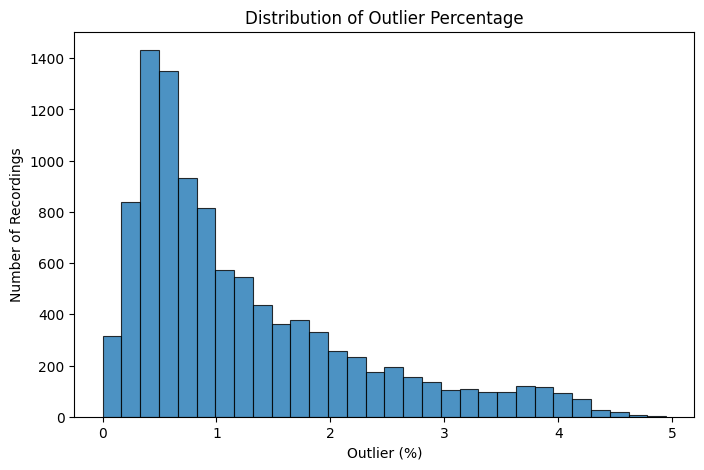

In [ ]:
# Outlier Distribution
plt.figure(figsize=(8,5))

plt.hist(quality_report["Outlier (%)"], 
            bins=30, 
            edgecolor="black",      # Draw borders around bars
            linewidth=0.8,
            alpha=0.8)

plt.xlabel("Outlier (%)")
plt.ylabel("Number of Recordings")

plt.title("Distribution of Outlier Percentage")

plt.show()

#### Observation:

The signal quality assessment indicates that the PADS movement dataset has a high level of data completeness and consistency. All recordings contain the expected number of samples, with no missing values, invalid values, or constant channels detected. Although the percentage of statistical outliers varies across recordings, most recordings exhibit low Outlier (%) values, and higher percentages are mainly associated with more dynamic movement tasks.

#### 6. Define Signal-Quality Assessment Rules

In [ ]:
signal_quality_rules = pd.DataFrame({

    "Quality Metric": [
        "Recording Length",
        "Missing Values",
        "Invalid Values",
        "Constant Channels",
        "Outlier (%)"
    ],

    "Acceptance Rule": [
        "Actual Rows = Expected Rows",
        "No missing values",
        "No infinite values",
        "No constant sensor channels",
        "Used as an exploratory indicator"
    ],

    "Rationale": [
        "Ensures the complete recording was collected.",
        "Missing samples may affect feature extraction.",
        "Infinite values indicate corrupted data.",
        "Constant channels suggest sensor malfunction or recording issues.",
        "High outlier percentages may reflect movement variability rather than poor quality."
    ]

})

signal_quality_rules

,Quality Metric,Acceptance Rule,Rationale
0,Recording Length,Actual Rows = Expected Rows,Ensures the complete recording was collected.
1,Missing Values,No missing values,Missing samples may affect feature extraction.
2,Invalid Values,No infinite values,Infinite values indicate corrupted data.
3,Constant Channels,No constant sensor channels,Constant channels suggest sensor malfunction o...
4,Outlier (%),Used as an exploratory indicator,High outlier percentages may reflect movement ...


#### Observation:

The exploratory analysis demonstrated that all movement recordings contained the expected number of samples and showed no missing values, invalid values, or constant sensor channels. Visual inspection of representative accelerometer and gyroscope recordings confirmed continuous and consistent signals across all sensor axes.

The Outlier (%) metric, computed using a Z-score threshold of |Z| > 3, showed generally low values across the dataset. Most recordings exhibited low percentages of statistical outliers, while the highest values were primarily associated with more dynamic movement tasks, such as LiftHold and CrossArms, rather than with visible sensor malfunctions or data acquisition errors.

#### Conclusion:

Based on the signal quality assessment, all evaluated recordings satisfied the established quality requirements. No evidence of incomplete recordings, missing values, invalid values, or constant sensor channels was found. Although the percentage of statistical outliers varied across recordings, Higher Outlier (%) values were primarily observed in dynamic movement tasks such as LiftHold and CrossArms, suggesting that these values may reflect task-related movement variability rather than sensor-quality issues. Consequently, no recordings were excluded based on the assessed quality assurance criteria, and all recordings were retained for subsequent preprocessing and feature extraction.